In [2]:
import numpy as np
import matplotlib.pyplot as plt

Finding the exact value of $u$

In [3]:
N_exact = 4
u_exact = lambda x: -2*x**2 + x 
x_exact = np.linspace(0, 1, N_exact)
u_exat = u_exact(x_exact)
print(u_exat)

[ 0.          0.11111111 -0.22222222 -1.        ]


Solving for $\textbf {FDM}$

i) Case Dirichlet-Dirichlet Boundary Conditions $u(0) = 0 $ and $u(1) = -1 $

In [4]:
f_x = lambda x: 4*x**2 - 2*x - 4
N_fdm_dd = N_exact-1
x_fdm_dd = np.linspace(0, 1, N_fdm_dd+1)
h_fdm = x_fdm_dd[1] - x_fdm_dd[0] 
print("The nodes are ",x_fdm_dd)
print("The f(x) values at different x values are :", f_x(x_fdm_dd))

n_int_fdm_dd = N_fdm_dd - 1
d_fdm_dd = -(2 + 2*h_fdm**2) * np.ones(n_int_fdm_dd)
od_fdm_dd = 1 * np.ones(n_int_fdm_dd-1)
A_fdm_dd = np.zeros((n_int_fdm_dd, n_int_fdm_dd))
#print(A_fdm_dd)
#Setting up the Stiffnedd matrix 
A_fdm_dd = np.diag(d_fdm_dd) + np.diag(od_fdm_dd, -1) + np.diag(od_fdm_dd, 1)
print("The A matrix is :")
print(A_fdm_dd)

u_fdm_dd = np.zeros(N_fdm_dd+1)
#Setting up the boundary conditions
u_fdm_dd[0] = 0
u_fdm_dd[-1] = -1

b = np.zeros(n_int_fdm_dd)
for i in range(0,N_fdm_dd-1):
    xi = x_fdm_dd[i+1]
    b[i] = h_fdm**2 * f_x(xi)

b[0] = b[0] - u_fdm_dd[0]
b[-1] = b[-1] - u_fdm_dd[-1]
print("The right hand side matrix is ")
print(b)

u_fdm_dd[1:-1] = np.linalg.solve(A_fdm_dd,b)
print("The calculated nodes values are : ")
print(u_fdm_dd)

The nodes are  [0.         0.33333333 0.66666667 1.        ]
The f(x) values at different x values are : [-4.         -4.22222222 -3.55555556 -2.        ]
The A matrix is :
[[-2.22222222  1.        ]
 [ 1.         -2.22222222]]
The right hand side matrix is 
[-0.4691358   0.60493827]
The calculated nodes values are : 
[ 0.          0.11111111 -0.22222222 -1.        ]


ii) Case Dirichlet-Neumann Boundary Conditions $u(0) = 0 $ and $\frac {du}{dx}|_1 = -3 $

In [5]:
N_fdm_dn = N_exact -1
x_fm = np.linspace(0, 1, N_fdm_dn+1)
h = x_fm[1] - x_fm[0]

n_int_fdm_dn = N_fdm_dn-1
d_fdm_dn = -(2 + 2*h**2) * np.ones(N_fdm_dn)
od_fdm_dn = 1 * np.ones(N_fdm_dn-1)
A_fdm_dn = np.zeros((N_fdm_dn + 1, N_fdm_dn + 1))
A_fdm_dn = np.diag(d_fdm_dn) + np.diag(od_fdm_dn, -1) + np.diag(od_fdm_dn, 1)
A_fdm_dn[-1,-1] = -2-2*h**2
A_fdm_dn[-1,-2] = 2
print("The matrix A is : ")
print(A_fdm_dn)

u_fm = np.zeros(N_fdm_dn+1)
u_fm[0] = 0

b_fm = np.zeros(N_fdm_dn)
for i in range(0,N_fdm_dn):
    xi = x_fm[i+1]
    b_fm[i] = h**2 * f_x(xi)

b_fm[0] = b_fm[0] - u_fm[0]
b_fm[-1] = (1)*b_fm[-1] + 6*h
print("The right hand side matrix is ")
print(b_fm)

u_fm[1:] = np.linalg.solve(A_fdm_dn,b_fm)
print("The calculated nodes values are : ")
print(u_fm)


The matrix A is : 
[[-2.22222222  1.          0.        ]
 [ 1.         -2.22222222  1.        ]
 [ 0.          2.         -2.22222222]]
The right hand side matrix is 
[-0.4691358  -0.39506173  1.77777778]
The calculated nodes values are : 
[ 0.          0.11111111 -0.22222222 -1.        ]


$\textbf{Plotting}$ 

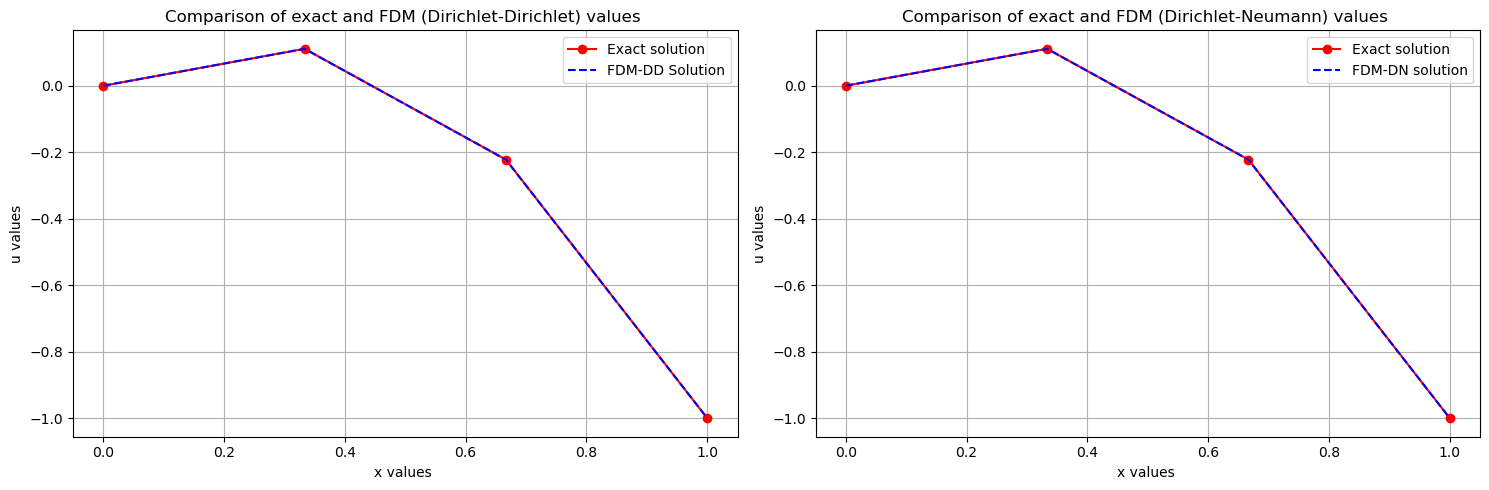

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

#first plot for fdm dd 
axes[0].plot(x_exact,u_exact(x_exact), 'ro-', label = "Exact solution")
axes[0].plot(x_fdm_dd,u_fdm_dd, 'b--', label ="FDM-DD Solution")
axes[0].set_xlabel('x values ')
axes[0].set_ylabel('u values')
axes[0].set_title("Comparison of exact and FDM (Dirichlet-Dirichlet) values ")
axes[0].legend()
axes[0].grid()

#second plot for fdm dn 
axes[1].plot(x_exact,u_exact(x_exact), 'ro-', label = "Exact solution")
axes[1].plot(x_fm,u_fm, 'b--', label ="FDM-DN solution")
axes[1].set_xlabel('x values ')
axes[1].set_ylabel('u values')
axes[1].set_title("Comparison of exact and FDM (Dirichlet-Neumann) values ")
axes[1].legend()
axes[1].grid()

plt.tight_layout()  # Avoid overlap
plt.show()

Solving for $\textbf{FEM}$

In [7]:
element = N_exact - 1
nodes = element + 1
f_x = lambda x: 4*x**2 - 2*x - 4

x_nodes = np.linspace(0,1,nodes)
h = x_nodes[1] - x_nodes[0]
print("The locations of nodes are : ")
print(x_nodes)
print("The spacing is ")
print(h)
print("The fucntion values at the nodes are ")
print(f_x(x_nodes))

The locations of nodes are : 
[0.         0.33333333 0.66666667 1.        ]
The spacing is 
0.3333333333333333
The fucntion values at the nodes are 
[-4.         -4.22222222 -3.55555556 -2.        ]


i) Case Dirichlet-Dirichlet Boundary Conditions $u(0) = 0 $ and $u(1) = -1 $

In [8]:
a_ij = (1/h) * np.array(([1, -1],
                         [-1, 1]))
b_ij = (2*h/6) * np.array(([2, 1],
                           [1, 2]))
k_local = a_ij + b_ij
print("The local stiffness matrix is ")
print(k_local)

k_global = np.zeros((nodes, nodes))
F_global = np.zeros(nodes)
for e in range(element):
  nodes_id = [e, e+1]
  for i in range(2):
    for j in range(2):
      k_global[nodes_id[i], nodes_id[j]] += k_local[i,j]
print("The global stiffness matrix is :")
print(k_global)

#Setting the load vector matrix  
def element_I_anal(xi, h):
  I_1 = h*(2*xi**2 - xi - 2 + (4/3)*h*xi -(1/3)*h + (1/3)*h**2)
  I_2 = h*(2*xi**2 - xi - 2 + (8/3)*h*xi -(2/3)*h + (1)*h**2)
  return I_1, I_2

I_global = np.zeros(nodes)
elemental_load = []
for e in range(element):
  xi = x_nodes[e]
  I_1, I_2 = element_I_anal(xi, h)
  elemental_load.append((I_1, I_2))
  I_global[e] += I_1
  I_global[e+1] += I_2
F_global = -I_global

print("The F matrix is : ")
print(F_global)

u_fem_dd = np.zeros(nodes)
u_fem_dd[0] = 0
u_fem_dd[-1] = -1

free_fem_dd = np.arange(1,nodes -1)
k_ff = k_global[np.ix_(free_fem_dd,free_fem_dd)]
F_f = F_global[free_fem_dd] - k_global[np.ix_(free_fem_dd,[0,nodes - 1])] @ u_fem_dd[[0, nodes-1]]
#print(F_f)

u_fem_dd[free_fem_dd] = np.linalg.solve(k_ff, F_f)
print("The calcualted nodes values are :")
print(u_fem_dd)

The local stiffness matrix is 
[[ 3.22222222 -2.88888889]
 [-2.88888889  3.22222222]]
The global stiffness matrix is :
[[ 3.22222222 -2.88888889  0.          0.        ]
 [-2.88888889  6.44444444 -2.88888889  0.        ]
 [ 0.         -2.88888889  6.44444444 -2.88888889]
 [ 0.          0.         -2.88888889  3.22222222]]
The F matrix is : 
[0.69135802 1.38271605 1.16049383 0.43209877]
The calcualted nodes values are :
[ 0.          0.11805556 -0.21527778 -1.        ]


ii) Case Dirichlet-Neumann Boundary Conditions $u(0) = 0 $ and $\frac{du}{dx}|_1 = -3 $

In [9]:
u_fem_dn = np.zeros(nodes)
u_fem_dn[0] = 0
G = np.zeros(nodes)
G[-1] = -3
free_fem_dn = np.arange(1, nodes)
k_ff = k_global[np.ix_(free_fem_dn,free_fem_dn)]
B = F_global + G
F_ff = B[free_fem_dn]
#F_ff[-1] =
#print(F_ff)

u_fem_dn[free_fem_dn] = np.linalg.solve(k_ff, F_ff)
print("The calculated nodal values are : ")
print(u_fem_dn)

The calculated nodal values are : 
[ 0.          0.12314452 -0.20392548 -0.97976461]


$\textbf{Plotting}$

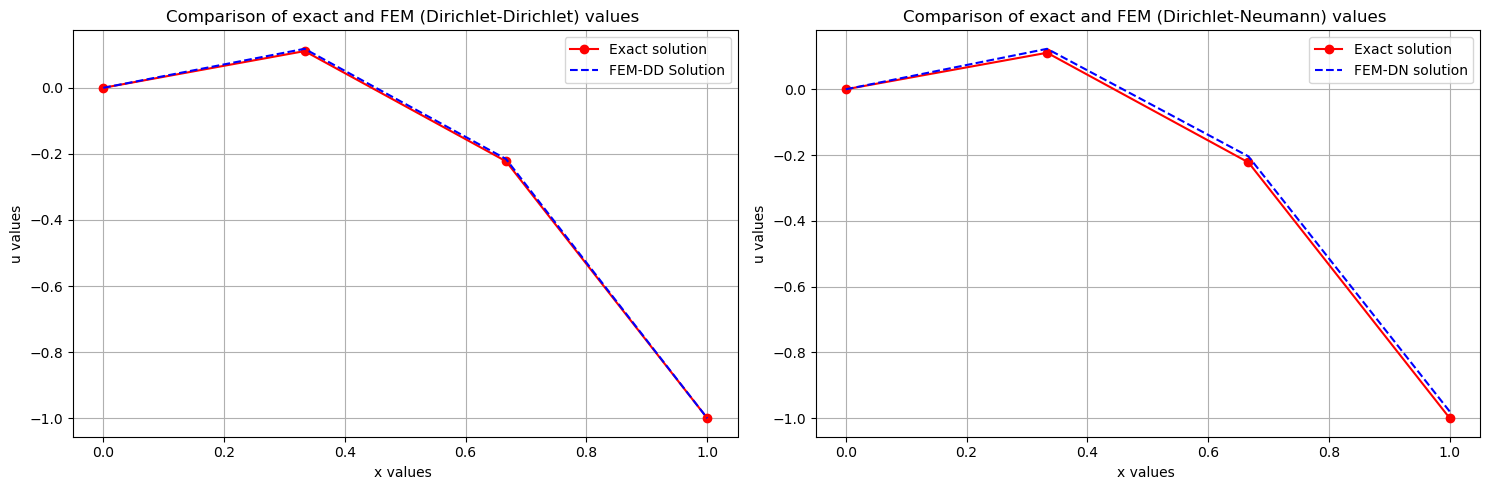

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

#first plot for fdm dd 
axes[0].plot(x_exact,u_exact(x_exact), 'ro-', label = "Exact solution")
axes[0].plot(x_nodes,u_fem_dd, 'b--', label ="FEM-DD Solution")
axes[0].set_xlabel('x values ')
axes[0].set_ylabel('u values')
axes[0].set_title("Comparison of exact and FEM (Dirichlet-Dirichlet) values ")
axes[0].legend()
axes[0].grid()

#second plot for fdm dn 
axes[1].plot(x_exact,u_exact(x_exact), 'ro-', label = "Exact solution")
axes[1].plot(x_nodes,u_fem_dn, 'b--', label ="FEM-DN solution")
axes[1].set_xlabel('x values ')
axes[1].set_ylabel('u values')
axes[1].set_title("Comparison of exact and FEM (Dirichlet-Neumann) values ")
axes[1].legend()
axes[1].grid()

plt.tight_layout()  # Avoid overlap
plt.show()

Solving for $\textbf{FVM}$

i) Case Dirichlet-Dirichlet Boundary Conditions $u(0) = 0 $ and $u(1) = -1 $

In [17]:
int_f = lambda x : 4*x**2 - 2*x -4
x_fvm_dd = np.linspace(0,1,N_exact)
h = x_fvm_dd[1] - x_fvm_dd[0]
x_cell = np.linspace(h/2, 1 - (h/2), N_exact - 1)
print("The cell face loactions are ")
print(x_fvm_dd)
print("The spacings are :")
print(h)
print("The cell nodes are at")
print(x_cell)

The cell face loactions are 
[0.         0.33333333 0.66666667 1.        ]
The spacings are :
0.3333333333333333
The cell nodes are at
[0.16666667 0.5        0.83333333]


ii) Case Dirichlet-Neumann Boundary Conditions $u(0) = 0 $ and $\frac{du}{dx}|_1 = -3 $

In [22]:
fvm_dd_nodes = N_exact - 2
A_fvm_dd = np.zeros((fvm_dd_nodes, fvm_dd_nodes))
F_dd = np.zeros(fvm_dd_nodes)
u_fvm_dd = np.zeros(N_exact)

u_fvm_dd[0] = 0
u_fvm_dd[-1] = -1
diagno_fvm_dd = -((2/h) + (2*h)) * np.ones(fvm_dd_nodes)
od_fvm_dd = (1/h) * np.ones(fvm_dd_nodes-1)
A_fvm_dd = np.diag(diagno_fvm_dd) + np.diag(od_fvm_dd, 1) + np.diag(od_fvm_dd, -1)
print("The matrix A is :")
print(A_fvm_dd)

F_dd = int_f(x_fvm_dd[1:-1]) * h
F_dd[0] = F_dd[0] - (u_fvm_dd[0]/h) 
F_dd[-1] = F_dd[-1] - (u_fvm_dd[-1]/h)
print("The right hand side of the matrix is ")
print(F_dd)

u_fvm_dd[1:-1] = np.linalg.solve(A_fvm_dd, F_dd)
print("The calculated cell center values are :")
print(u_fvm_dd)

The matrix A is :
[[-6.66666667  3.        ]
 [ 3.         -6.66666667]]
The right hand side of the matrix is 
[-1.40740741  1.81481481]
The calculated cell center values are :
[ 0.          0.11111111 -0.22222222 -1.        ]


In [26]:
fvm_dn_nodes = N_exact - 1
A_fvm_dn = np.zeros((fvm_dn_nodes, fvm_dn_nodes))
F_dn = np.zeros(fvm_dn_nodes)
u_dn = np.zeros(N_exact)
u_dn[0] = 0

diagno_fvm_dn = -(2+2*h**2) * np.ones(fvm_dn_nodes)
od_fvm_dn = (1)*np.ones(fvm_dn_nodes-1)
A_fvm_dn = np.diag(diagno_fvm_dn) + np.diag(od_fvm_dn, 1) + np.diag(od_fvm_dn, -1)
A_fvm_dn[-1,-2] = 1*2
print("The matrix A is :")
print(A_fvm_dn)
F_dn = int_f(x_fvm_dd[1:])*(h**2)
F_dn[0] = F_dn[0] - (u_dn[0])
F_dn[-1] = F_dn[-1] + (6*h)
print("The right hand side of matrix is : ")
print(F_dn)

u_dn[1:] = np.linalg.solve(A_fvm_dn, F_dn)
print("The calculated cell center values are :")
print(u_dn)


The matrix A is :
[[-2.22222222  1.          0.        ]
 [ 1.         -2.22222222  1.        ]
 [ 0.          2.         -2.22222222]]
The right hand side of matrix is : 
[-0.4691358  -0.39506173  1.77777778]
The calculated cell center values are :
[ 0.          0.11111111 -0.22222222 -1.        ]


$\textbf{Plotting}$

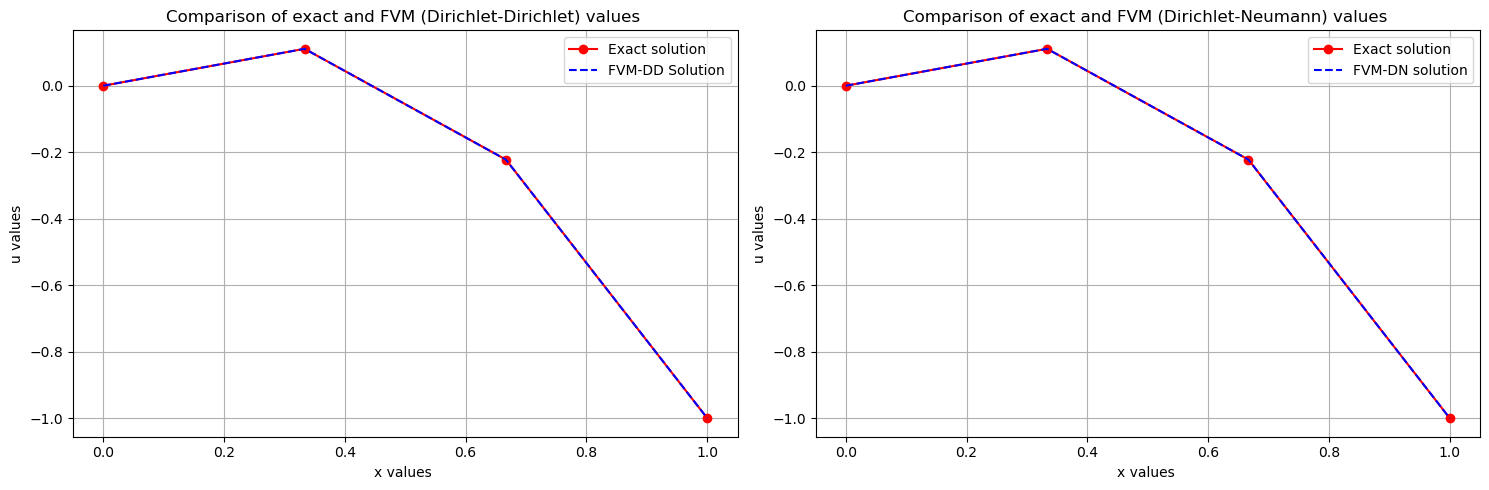

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

#first plot for fdm dd 
axes[0].plot(x_exact,u_exact(x_exact), 'ro-', label = "Exact solution")
axes[0].plot(x_fvm_dd,u_fvm_dd, 'b--', label ="FVM-DD Solution")
axes[0].set_xlabel('x values ')
axes[0].set_ylabel('u values')
axes[0].set_title("Comparison of exact and FVM (Dirichlet-Dirichlet) values ")
axes[0].legend()
axes[0].grid()

#second plot for fdm dn 
axes[1].plot(x_exact,u_exact(x_exact), 'ro-', label = "Exact solution")
axes[1].plot(x_fvm_dd,u_dn, 'b--', label ="FVM-DN solution")
axes[1].set_xlabel('x values ')
axes[1].set_ylabel('u values')
axes[1].set_title("Comparison of exact and FVM (Dirichlet-Neumann) values ")
axes[1].legend()
axes[1].grid()

plt.tight_layout()  # Avoid overlap
plt.show()